# ============================================================
# SECTION 3: TRAINING MODEL
# ============================================================
# Jalankan setelah Section 1
# Section 2 tidak wajib dijalankan sebelum ini
# Output: session_training.pkl + model_*.keras
# ============================================================

In [85]:
# ------------------------------------------------------------
# Load hasil preprocessing
# ------------------------------------------------------------

import pickle
import numpy as np
import tensorflow as tf

with open('session_preprocessing.pkl', 'rb') as f:
    sv = pickle.load(f)

le             = sv['le']
scaler         = sv['scaler']
ecocrop        = sv['ecocrop']
X_train_scaled = sv['X_train_scaled']
X_val_scaled   = sv['X_val_scaled']
X_test_scaled  = sv['X_test_scaled']
y_train_oh     = sv['y_train_oh']
y_val_oh       = sv['y_val_oh']
y_test_oh      = sv['y_test_oh']

print("✅ Preprocessing dimuat")

✅ Preprocessing dimuat


In [86]:
# ------------------------------------------------------------
# 3.1 Bangun Physics Constraint Tensors
# ------------------------------------------------------------
TEMP_IDX = 3
PH_IDX = 5
CLASS_NAMES = list(le.classes_)

physics_mu = np.zeros((22, 2))
physics_sigma = np.zeros((22, 2))

for i, crop in enumerate(CLASS_NAMES):
    for j, feat in enumerate(['temperature', 'ph']):
        min_val = ecocrop[crop][feat][0]
        max_val = ecocrop[crop][feat][1]
        physics_mu[i, j] = (max_val + min_val) / 2
        physics_sigma[i, j] = (max_val - min_val) / 6

# Scale μ dan σ agar konsisten dengan StandardScaler
scaler_mean = scaler.mean_
scaler_std = scaler.scale_
feat_indices = [TEMP_IDX, PH_IDX]

physics_mu_scaled = (physics_mu - scaler_mean[feat_indices]) / scaler_std[feat_indices]
physics_sigma_scaled = physics_sigma / scaler_std[feat_indices]

# Konversi ke TensorFlow constant
physics_mu_tf = tf.constant(physics_mu_scaled,    dtype=tf.float32)
physics_sigma_tf = tf.constant(physics_sigma_scaled, dtype=tf.float32)

print("✅ Physics constraint tensors siap\n")

✅ Physics constraint tensors siap



In [ ]:
# ------------------------------------------------------------
# 3.2 Loss Functions
# ------------------------------------------------------------
# ------------------------------------------------------------
# 3a. Data Loss — Categorical Cross-Entropy
# Rujukan: BAB 3 hal 50, formula L_data
#
# L_data = -1/N Σ Σ y_ic × log(ŷ_ic)
# ------------------------------------------------------------
def data_loss_fn(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    return -tf.reduce_mean(tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1))

# ------------------------------------------------------------
# 3b. Physics Loss — Environmental Suitability
# Rujukan: BAB 3 hal 50-51, formula L_physics
#
# temp_score    = exp(-(T_input - μ_T,c)² / 2σ²_T,c)
# pH_score      = exp(-(pH_input - μ_pH,c)² / 2σ²_pH,c)
# env_score     = temp_score × pH_score
# L_physics     = (1 - crop_prob) × env_score
#
# PENTING: crop_prob dan env_score diambil untuk
# kelas GROUND TRUTH saja
# ------------------------------------------------------------
def physics_loss_fn(X_batch, y_pred, y_true):
    # Ambil fitur lingkungan dari input (sudah scaled)
    temp = X_batch[:, TEMP_IDX:TEMP_IDX+1]         # (batch, 1)
    ph   = X_batch[:, PH_IDX:PH_IDX+1]             # (batch, 1)

    # μ dan σ untuk semua 22 kelas (sudah scaled)
    mu_t  = physics_mu_tf[:, 0]    # (22,)
    mu_p  = physics_mu_tf[:, 1]    # (22,)
    sig_t = physics_sigma_tf[:, 0] # (22,)
    sig_p = physics_sigma_tf[:, 1] # (22,)

    # Gaussian score untuk setiap kelas
    # Shape: (batch, 22)
    temp_score = tf.exp(-tf.square(temp - mu_t) / (2 * tf.square(sig_t)))
    ph_score   = tf.exp(-tf.square(ph   - mu_p) / (2 * tf.square(sig_p)))

    # env_score untuk semua kelas: (batch, 22)
    env_score = temp_score * ph_score

    # Ambil env_score untuk kelas GROUND TRUTH saja
    # y_true adalah one-hot → multiply + sum = ambil nilai GT
    env_score_gt  = tf.reduce_sum(y_true * env_score, axis=1)  # (batch,)

    # Ambil crop_prob untuk kelas GROUND TRUTH saja
    crop_prob_gt = tf.reduce_sum(y_true * y_pred, axis=1)       # (batch,)

    # Physics loss: (1 - crop_prob) × env_score
    # Harus selalu [0, 1]
    physics_loss = tf.reduce_mean((1 - crop_prob_gt) * env_score_gt)

    return physics_loss

# Test kedua loss function
print("=== TEST LOSS FUNCTIONS ===")
X_test_tf = tf.constant(X_train_scaled[:32], dtype=tf.float32)
y_test_tf = tf.constant(y_train_oh[:32],     dtype=tf.float32)

# Buat model dummy untuk test
test_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(7,)),
    tf.keras.layers.Dense(22, activation='relu'),
    tf.keras.layers.Dense(22, activation='softmax')
])
y_pred_test = test_model(X_test_tf)

dl = data_loss_fn(y_test_tf, y_pred_test)
pl = physics_loss_fn(X_test_tf, y_pred_test, y_test_tf)

print(f"Data loss    : {dl.numpy():.4f} (harusnya ~3.09 di awal)")
print(f"Physics loss : {pl.numpy():.4f} (harusnya 0-1, tidak negatif!)")

# Verifikasi physics loss tidak negatif
assert pl.numpy() >= 0, "❌ Physics loss negatif!"
print(f"\n✅ Physics loss positif dan valid!")

=== TEST LOSS FUNCTIONS ===
Data loss    : 3.1990 (harusnya ~3.09 di awal)
Physics loss : 0.1081 (harusnya 0-1, tidak negatif!)

✅ Physics loss positif dan valid!


In [88]:
# ------------------------------------------------------------
# 3.3 Arsitektur Model MLP
# Rujukan: BAB 3 hal 46-47, Tabel 3.9
# Input  (7)  → Hidden 1 (64, ReLU) →
# Hidden 2 (32, ReLU) → Output (22, Softmax)
# Total parameter: 3.318
# ------------------------------------------------------------
def build_mlp():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(7,)),
        tf.keras.layers.Dense(22, activation='relu'),
        tf.keras.layers.Dense(22, activation='softmax')
    ])
    return model

# Verifikasi
test_model = build_mlp()
test_model.summary()

total_params = test_model.count_params()
print(f"\n✅ Total parameter: {total_params} (sesuai proposal)")

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 22)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 22)             │           506 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682 (2.66 KB)

 Trainable params: 682 (2.66 KB)

 Non-trainable params: 0 (0.00 B)


✅ Total parameter: 682 (sesuai proposal)


In [89]:
# ============================================================
# 3.4 Training Loop
# Rujukan: BAB 3 hal 47-57
# ============================================================

# ============================================================
# CELL 5: Training Loop dengan Early Stopping & Random Seed
# ============================================================

import random

# Random Seed untuk reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ Random seed = {SEED} diterapkan")

def train_model(model, X_tr, y_tr, X_vl, y_vl,
                loss_fn, epochs=100, batch_size=32, 
                lr=0.001, patience=10):

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    history   = {
        'train_loss': [], 'val_loss': [],
        'train_acc' : [], 'val_acc' : []
    }
    n = X_tr.shape[0]

    # Early stopping setup
    best_val_loss    = np.inf
    patience_counter = 0
    best_weights     = None
    best_epoch       = 0

    for epoch in range(epochs):
        # Shuffle dengan seed yang reproducible
        np.random.seed(SEED + epoch)
        idx  = np.random.permutation(n)
        X_tr = X_tr[idx]
        y_tr = y_tr[idx]

        # === TRAINING ===
        train_losses  = []
        train_correct = 0

        for i in range(0, n, batch_size):
            X_batch = tf.constant(X_tr[i:i+batch_size], dtype=tf.float32)
            y_batch = tf.constant(y_tr[i:i+batch_size], dtype=tf.float32)

            with tf.GradientTape() as tape:
                loss = loss_fn(model, X_batch, y_batch)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            train_losses.append(loss.numpy())

            y_pred_batch  = model(X_batch, training=False)
            train_correct += np.sum(
                np.argmax(y_pred_batch.numpy(), axis=1) ==
                np.argmax(y_batch.numpy(), axis=1)
            )

        # === VALIDATION ===
        X_vl_tf  = tf.constant(X_vl, dtype=tf.float32)
        y_vl_tf  = tf.constant(y_vl, dtype=tf.float32)
        val_loss = loss_fn(model, X_vl_tf, y_vl_tf).numpy()
        y_pred_v = model(X_vl_tf, training=False)
        val_acc  = np.mean(
            np.argmax(y_pred_v.numpy(), axis=1) ==
            np.argmax(y_vl, axis=1)
        )
        train_acc = train_correct / n

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | "
                  f"train_loss: {np.mean(train_losses):.4f} | "
                  f"val_loss: {val_loss:.4f} | "
                  f"train_acc: {train_acc:.4f} | "
                  f"val_acc: {val_acc:.4f}")

        # === EARLY STOPPING ===
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_weights     = model.get_weights()
            best_epoch       = epoch + 1
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping di epoch {epoch+1} "
                      f"(best epoch: {best_epoch}, "
                      f"best val_loss: {best_val_loss:.4f})")
                break

    # Restore bobot terbaik
    if best_weights is not None:
        model.set_weights(best_weights)
        print(f"✅ Bobot dikembalikan ke epoch {best_epoch}")

    return history, best_epoch

print("✅ Training loop siap")

✅ Random seed = 42 diterapkan
✅ Training loop siap


In [90]:
# ============================================================
# 3.5 Train Baseline MLP
# Loss: L_data saja (tanpa physics loss)
# Sebagai pembanding untuk membuktikan efek physics loss
# ============================================================

# ============================================================
# CELL 6: Train Baseline MLP
# ============================================================

def baseline_loss_fn(model, X_batch, y_batch):
    y_pred = model(X_batch, training=True)
    return data_loss_fn(y_batch, y_pred)

print("=== TRAINING BASELINE MLP ===\n")
tf.random.set_seed(SEED)
model_baseline           = build_mlp()
history_baseline, best_epoch_baseline = train_model(
    model_baseline,
    X_train_scaled, y_train_oh,
    X_val_scaled,   y_val_oh,
    baseline_loss_fn,
    epochs=100, patience=10
)

print(f"\n✅ Baseline selesai")
print(f"   Best Epoch    : {best_epoch_baseline}")
print(f"   Best Val Acc  : {max(history_baseline['val_acc']):.4f}")
print(f"   Final Val Acc : {history_baseline['val_acc'][-1]:.4f}")

=== TRAINING BASELINE MLP ===

Epoch  10 | train_loss: 0.9575 | val_loss: 0.9119 | train_acc: 0.8214 | val_acc: 0.8455
Epoch  20 | train_loss: 0.4249 | val_loss: 0.4146 | train_acc: 0.9188 | val_acc: 0.9182
Epoch  30 | train_loss: 0.2553 | val_loss: 0.2574 | train_acc: 0.9474 | val_acc: 0.9424
Epoch  40 | train_loss: 0.1820 | val_loss: 0.1807 | train_acc: 0.9649 | val_acc: 0.9576
Epoch  50 | train_loss: 0.1347 | val_loss: 0.1368 | train_acc: 0.9714 | val_acc: 0.9727
Epoch  60 | train_loss: 0.1084 | val_loss: 0.1091 | train_acc: 0.9779 | val_acc: 0.9848
Epoch  70 | train_loss: 0.0920 | val_loss: 0.0907 | train_acc: 0.9812 | val_acc: 0.9848
Epoch  80 | train_loss: 0.0742 | val_loss: 0.0772 | train_acc: 0.9825 | val_acc: 0.9848
Epoch  90 | train_loss: 0.0656 | val_loss: 0.0675 | train_acc: 0.9857 | val_acc: 0.9848
Epoch 100 | train_loss: 0.0571 | val_loss: 0.0597 | train_acc: 0.9864 | val_acc: 0.9848
✅ Bobot dikembalikan ke epoch 100

✅ Baseline selesai
   Best Epoch    : 100
   Best Val 

In [91]:
# ============================================================
# 3.6 Train Fixed-weight PINN
# Loss: L_total = L_data + λ × L_physics
# λ = 1.0 (nilai awal standar PINN, saran pembimbing)
# Rujukan: BAB 3 hal 52
# ============================================================

# ============================================================
# CELL 7: Train Fixed-weight PINN
# ============================================================

LAMBDA_PHYSICS = 1.0

def pinn_fixed_loss_fn(model, X_batch, y_batch):
    y_pred    = model(X_batch, training=True)
    l_data    = data_loss_fn(y_batch, y_pred)
    l_physics = physics_loss_fn(X_batch, y_pred, y_batch)
    return l_data + LAMBDA_PHYSICS * l_physics

print(f"=== TRAINING FIXED-PINN (λ={LAMBDA_PHYSICS}) ===\n")
tf.random.set_seed(SEED)
model_pinn           = build_mlp()
history_pinn, best_epoch_pinn = train_model(
    model_pinn,
    X_train_scaled, y_train_oh,
    X_val_scaled,   y_val_oh,
    pinn_fixed_loss_fn,
    epochs=100, patience=10
)

print(f"\n✅ Fixed-PINN selesai")
print(f"   Best Epoch    : {best_epoch_pinn}")
print(f"   Best Val Acc  : {max(history_pinn['val_acc']):.4f}")
print(f"   Final Val Acc : {history_pinn['val_acc'][-1]:.4f}")

=== TRAINING FIXED-PINN (λ=1.0) ===

Epoch  10 | train_loss: 1.0862 | val_loss: 1.0117 | train_acc: 0.8169 | val_acc: 0.8364
Epoch  20 | train_loss: 0.4436 | val_loss: 0.4154 | train_acc: 0.9195 | val_acc: 0.9212
Epoch  30 | train_loss: 0.2636 | val_loss: 0.2536 | train_acc: 0.9506 | val_acc: 0.9455
Epoch  40 | train_loss: 0.1867 | val_loss: 0.1776 | train_acc: 0.9682 | val_acc: 0.9667
Epoch  50 | train_loss: 0.1378 | val_loss: 0.1354 | train_acc: 0.9747 | val_acc: 0.9727
Epoch  60 | train_loss: 0.1109 | val_loss: 0.1099 | train_acc: 0.9773 | val_acc: 0.9727
Epoch  70 | train_loss: 0.0941 | val_loss: 0.0927 | train_acc: 0.9838 | val_acc: 0.9788
Epoch  80 | train_loss: 0.0768 | val_loss: 0.0801 | train_acc: 0.9864 | val_acc: 0.9879
Epoch  90 | train_loss: 0.0680 | val_loss: 0.0703 | train_acc: 0.9870 | val_acc: 0.9909
Epoch 100 | train_loss: 0.0588 | val_loss: 0.0626 | train_acc: 0.9896 | val_acc: 0.9909
✅ Bobot dikembalikan ke epoch 100

✅ Fixed-PINN selesai
   Best Epoch    : 100
   B

In [92]:
# ============================================================
# CELL 8: Train lbPINN
# ============================================================

# Reset epsilon setiap training
log_eps_data    = tf.Variable(0.0, trainable=True, dtype=tf.float32)
log_eps_physics = tf.Variable(0.0, trainable=True, dtype=tf.float32)

def lbpinn_loss_fn(model, X_batch, y_batch):
    y_pred    = model(X_batch, training=True)
    l_data    = data_loss_fn(y_batch, y_pred)
    l_physics = physics_loss_fn(X_batch, y_pred, y_batch)
    eps_d     = tf.exp(log_eps_data)
    eps_p     = tf.exp(log_eps_physics)
    return (1 / (2 * tf.square(eps_d))) * l_data + \
           (1 / (2 * tf.square(eps_p))) * l_physics + \
           tf.math.log(eps_d * eps_p)

optimizer_lb = tf.keras.optimizers.Adam(learning_rate=0.001)
tf.random.set_seed(SEED)
model_lbpinn = build_mlp()

history_lbpinn = {
    'train_loss' : [], 'val_loss'    : [],
    'train_acc'  : [], 'val_acc'     : [],
    'eps_data'   : [], 'eps_physics' : []
}

print("=== TRAINING lbPINN ===\n")
epochs     = 100
batch_size = 32
patience   = 10
n          = X_train_scaled.shape[0]
X_tr       = X_train_scaled.copy()
y_tr       = y_train_oh.copy()

# Early stopping setup
best_val_loss_lb    = np.inf
patience_counter_lb = 0
best_weights_lb     = None
best_epoch_lb       = 0
best_eps_d          = None
best_eps_p          = None

for epoch in range(epochs):
    # Shuffle
    np.random.seed(SEED + epoch)
    idx  = np.random.permutation(n)
    X_tr = X_tr[idx]
    y_tr = y_tr[idx]

    train_losses  = []
    train_correct = 0

    for i in range(0, n, batch_size):
        X_batch  = tf.constant(X_tr[i:i+batch_size], dtype=tf.float32)
        y_batch  = tf.constant(y_tr[i:i+batch_size], dtype=tf.float32)
        all_vars = model_lbpinn.trainable_variables + \
                   [log_eps_data, log_eps_physics]

        with tf.GradientTape() as tape:
            loss = lbpinn_loss_fn(model_lbpinn, X_batch, y_batch)

        grads = tape.gradient(loss, all_vars)
        optimizer_lb.apply_gradients(zip(grads, all_vars))
        train_losses.append(loss.numpy())

        y_pred_batch  = model_lbpinn(X_batch, training=False)
        train_correct += np.sum(
            np.argmax(y_pred_batch.numpy(), axis=1) ==
            np.argmax(y_batch.numpy(), axis=1)
        )

    # Validation
    X_vl_tf  = tf.constant(X_val_scaled, dtype=tf.float32)
    y_vl_tf  = tf.constant(y_val_oh,     dtype=tf.float32)
    val_loss = lbpinn_loss_fn(model_lbpinn, X_vl_tf, y_vl_tf).numpy()
    y_pred_v = model_lbpinn(X_vl_tf, training=False)
    val_acc  = np.mean(
        np.argmax(y_pred_v.numpy(), axis=1) ==
        np.argmax(y_val_oh, axis=1)
    )
    train_acc = train_correct / n
    eps_d     = tf.exp(log_eps_data).numpy()
    eps_p     = tf.exp(log_eps_physics).numpy()

    history_lbpinn['train_loss'].append(np.mean(train_losses))
    history_lbpinn['val_loss'].append(val_loss)
    history_lbpinn['train_acc'].append(train_acc)
    history_lbpinn['val_acc'].append(val_acc)
    history_lbpinn['eps_data'].append(eps_d)
    history_lbpinn['eps_physics'].append(eps_p)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"train_loss: {np.mean(train_losses):.4f} | "
              f"val_loss: {val_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"val_acc: {val_acc:.4f} | "
              f"ε_data: {eps_d:.4f} | "
              f"ε_physics: {eps_p:.4f}")

    # Early stopping untuk lbPINN
    if val_loss < best_val_loss_lb:
        best_val_loss_lb    = val_loss
        patience_counter_lb = 0
        best_weights_lb     = model_lbpinn.get_weights()
        best_epoch_lb       = epoch + 1
        best_eps_d          = eps_d
        best_eps_p          = eps_p
    else:
        patience_counter_lb += 1
        if patience_counter_lb >= patience:
            print(f"\n⏹ Early stopping di epoch {epoch+1} "
                  f"(best epoch: {best_epoch_lb}, "
                  f"best val_loss: {best_val_loss_lb:.4f})")
            break

# Restore bobot terbaik
if best_weights_lb is not None:
    model_lbpinn.set_weights(best_weights_lb)
    print(f"✅ Bobot dikembalikan ke epoch {best_epoch_lb}")

print(f"\n✅ lbPINN selesai")
print(f"   Best Epoch      : {best_epoch_lb}")
print(f"   Best Val Acc    : {max(history_lbpinn['val_acc']):.4f}")
print(f"   Final Val Acc   : {history_lbpinn['val_acc'][-1]:.4f}")
print(f"   ε_data terbaik  : {best_eps_d:.4f}")
print(f"   ε_physics terbaik: {best_eps_p:.4f}")

=== TRAINING lbPINN ===

Epoch  10 | train_loss: 0.1844 | val_loss: 0.1366 | train_acc: 0.7812 | val_acc: 0.7818 | ε_data: 1.1802 | ε_physics: 0.6178
Epoch  20 | train_loss: -0.7443 | val_loss: -0.7976 | train_acc: 0.9156 | val_acc: 0.9030 | ε_data: 0.8654 | ε_physics: 0.3782
Epoch  30 | train_loss: -1.6302 | val_loss: -1.6676 | train_acc: 0.9623 | val_acc: 0.9576 | ε_data: 0.5705 | ε_physics: 0.2328
Epoch  40 | train_loss: -2.3821 | val_loss: -2.3950 | train_acc: 0.9792 | val_acc: 0.9727 | ε_data: 0.3916 | ε_physics: 0.1460
Epoch  50 | train_loss: -2.9546 | val_loss: -2.9182 | train_acc: 0.9831 | val_acc: 0.9758 | ε_data: 0.2985 | ε_physics: 0.0964
Epoch  60 | train_loss: -3.3445 | val_loss: -3.2347 | train_acc: 0.9838 | val_acc: 0.9788 | ε_data: 0.2518 | ε_physics: 0.0682
Epoch  70 | train_loss: -3.5681 | val_loss: -3.4060 | train_acc: 0.9877 | val_acc: 0.9788 | ε_data: 0.2292 | ε_physics: 0.0534
Epoch  80 | train_loss: -3.8096 | val_loss: -3.5249 | train_acc: 0.9870 | val_acc: 0.978

In [93]:
# ============================================================
# CELL 9: Simpan Model dan History
# ============================================================

saved_training = {
    'history_baseline': history_baseline,
    'history_pinn'    : history_pinn,
    'history_lbpinn'  : history_lbpinn,
    'best_lambda'     : LAMBDA_PHYSICS,
}

with open('session_training.pkl', 'wb') as f:
    pickle.dump(saved_training, f)

model_baseline.save('model_baseline.keras')
model_pinn.save('model_pinn.keras')
model_lbpinn.save('model_lbpinn.keras')

print("✅ Model disimpan: model_baseline.keras, model_pinn.keras, model_lbpinn.keras")
print("✅ History disimpan: session_training.pkl")

✅ Model disimpan: model_baseline.keras, model_pinn.keras, model_lbpinn.keras
✅ History disimpan: session_training.pkl


In [94]:
# ============================================================
# CELL 10: Evaluasi Test Set
# Rujukan: BAB 3 hal 58-60, Persamaan evaluasi
#
# Accuracy  = (TP + TN) / (TP + TN + FP + FN)
# Precision = TP / (TP + FP)
# Recall    = TP / (TP + FN)
# F1-Score  = 2 × (Precision × Recall) / (Precision + Recall)
#
# Semua metrik menggunakan macro averaging
# karena 22 kelas dengan distribusi seimbang
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score,
    confusion_matrix, classification_report
)

def evaluate_model(model, X_test, y_test_oh, model_name):
    """
    Evaluasi model pada test set
    
    Args:
        model      : model yang sudah ditraining
        X_test     : test features (scaled)
        y_test_oh  : test labels (one-hot)
        model_name : nama model untuk display
    """
    X_test_tf = tf.constant(X_test, dtype=tf.float32)
    y_pred    = model(X_test_tf, training=False).numpy()
    
    # Konversi dari one-hot / probabilitas ke label
    y_true_labels = np.argmax(y_test_oh, axis=1)
    y_pred_labels = np.argmax(y_pred,    axis=1)
    
    # Hitung metrik
    acc  = accuracy_score(y_true_labels, y_pred_labels)
    prec = precision_score(y_true_labels, y_pred_labels, 
                          average='macro', zero_division=0)
    rec  = recall_score(y_true_labels, y_pred_labels,    
                       average='macro', zero_division=0)
    f1   = f1_score(y_true_labels, y_pred_labels,        
                   average='macro', zero_division=0)
    cm   = confusion_matrix(y_true_labels, y_pred_labels)
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
    print(f"  Recall    : {rec:.4f} ({rec*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f} ({f1*100:.2f}%)")
    
    return {
        'model_name'   : model_name,
        'accuracy'     : acc,
        'precision'    : prec,
        'recall'       : rec,
        'f1_score'     : f1,
        'confusion_matrix': cm,
        'y_true'       : y_true_labels,
        'y_pred'       : y_pred_labels
    }

# Evaluasi ketiga model
print("=== EVALUASI TEST SET ===")

results_baseline = evaluate_model(
    model_baseline, X_test_scaled, y_test_oh, 
    "Baseline MLP"
)
results_pinn = evaluate_model(
    model_pinn, X_test_scaled, y_test_oh,
    "Fixed-PINN (λ=1.0)"
)
results_lbpinn = evaluate_model(
    model_lbpinn, X_test_scaled, y_test_oh,
    "lbPINN"
)

# Tabel perbandingan
print(f"\n{'='*60}")
print(f"  PERBANDINGAN HASIL")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"{'-'*60}")

for r in [results_baseline, results_pinn, results_lbpinn]:
    print(f"{r['model_name']:<20} "
          f"{r['accuracy']*100:>9.2f}% "
          f"{r['precision']*100:>9.2f}% "
          f"{r['recall']*100:>9.2f}% "
          f"{r['f1_score']*100:>9.2f}%")

=== EVALUASI TEST SET ===

  Baseline MLP
  Accuracy  : 0.9939 (99.39%)
  Precision : 0.9943 (99.43%)
  Recall    : 0.9939 (99.39%)
  F1-Score  : 0.9939 (99.39%)

  Fixed-PINN (λ=1.0)
  Accuracy  : 0.9818 (98.18%)
  Precision : 0.9822 (98.22%)
  Recall    : 0.9818 (98.18%)
  F1-Score  : 0.9818 (98.18%)

  lbPINN
  Accuracy  : 0.9848 (98.48%)
  Precision : 0.9854 (98.54%)
  Recall    : 0.9848 (98.48%)
  F1-Score  : 0.9848 (98.48%)

  PERBANDINGAN HASIL
Model                  Accuracy  Precision     Recall         F1
------------------------------------------------------------
Baseline MLP             99.39%     99.43%     99.39%     99.39%
Fixed-PINN (λ=1.0)       98.18%     98.22%     98.18%     98.18%
lbPINN                   98.48%     98.54%     98.48%     98.48%


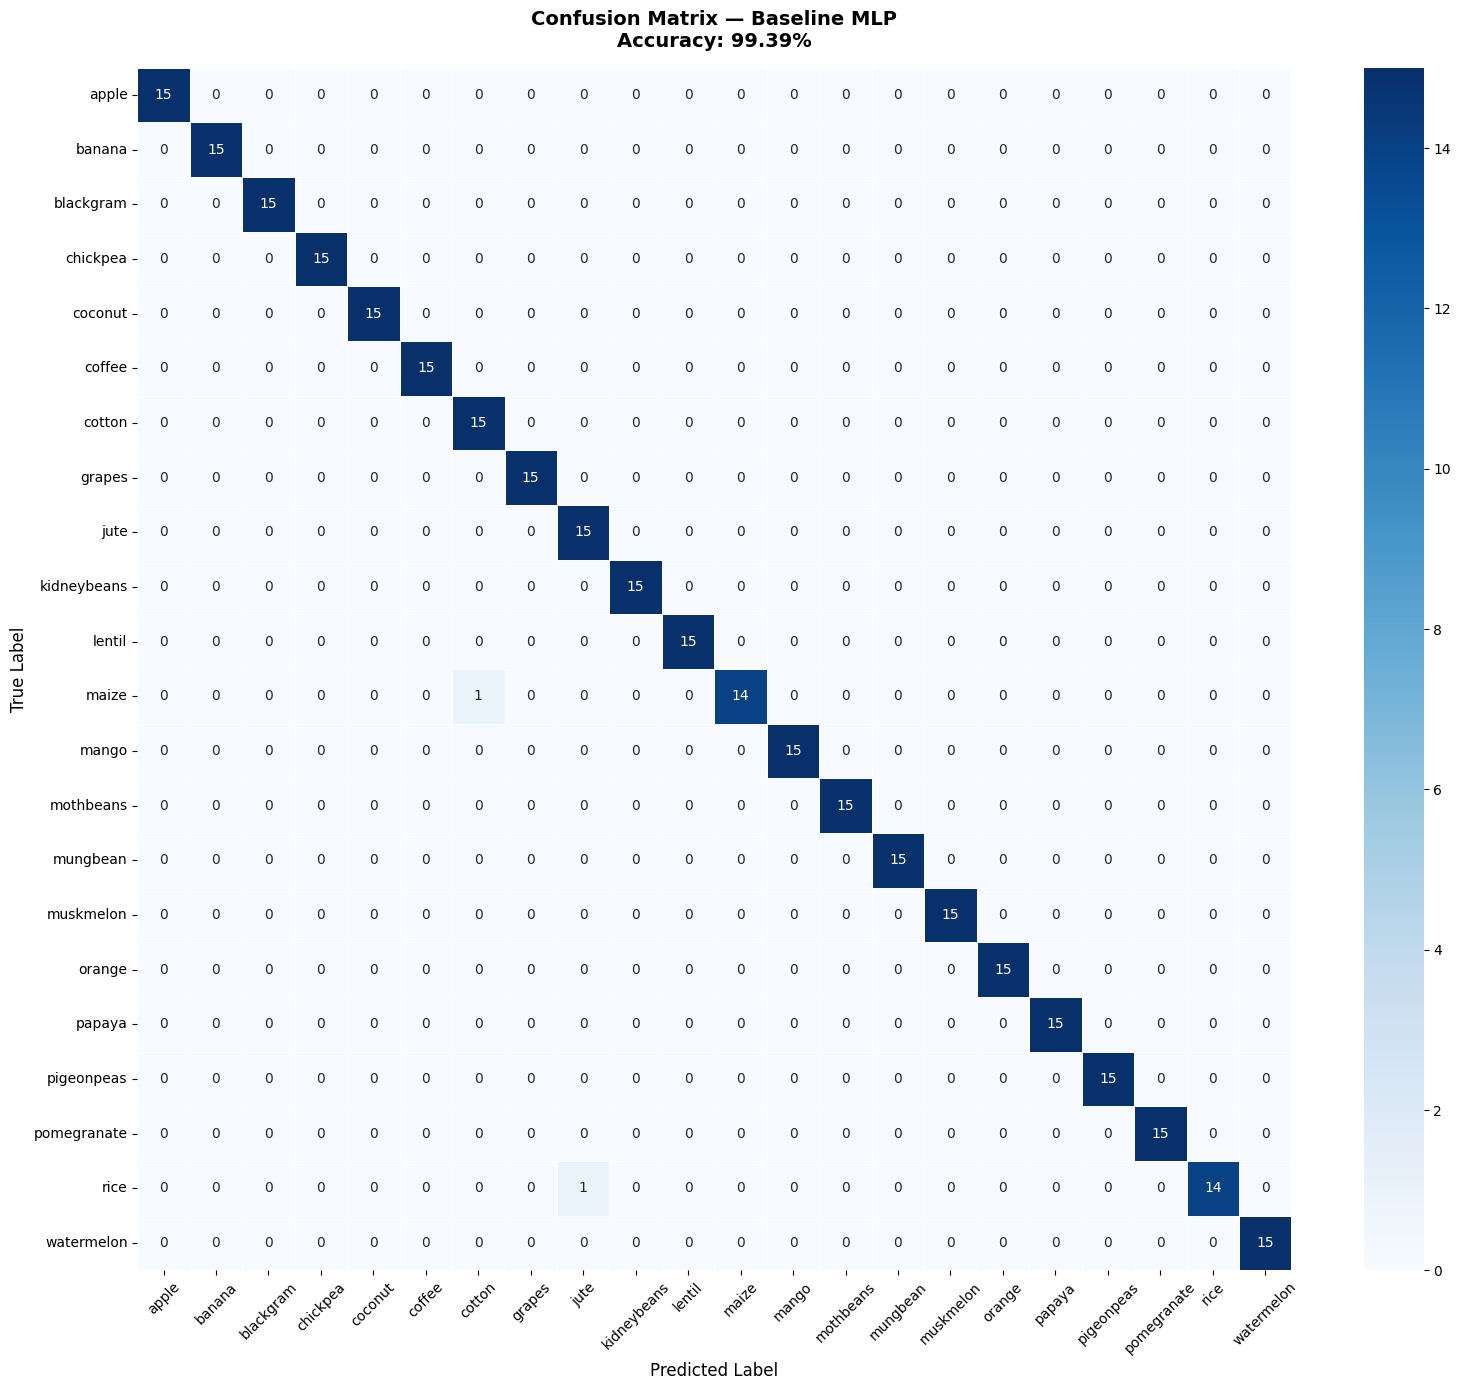

✅ Confusion matrix Baseline MLP disimpan

=== MISCLASSIFIKASI Baseline MLP ===
  maize           → diprediksi cotton          : 1 sampel
  rice            → diprediksi jute            : 1 sampel

  Total salah: 2 dari 330 sampel test



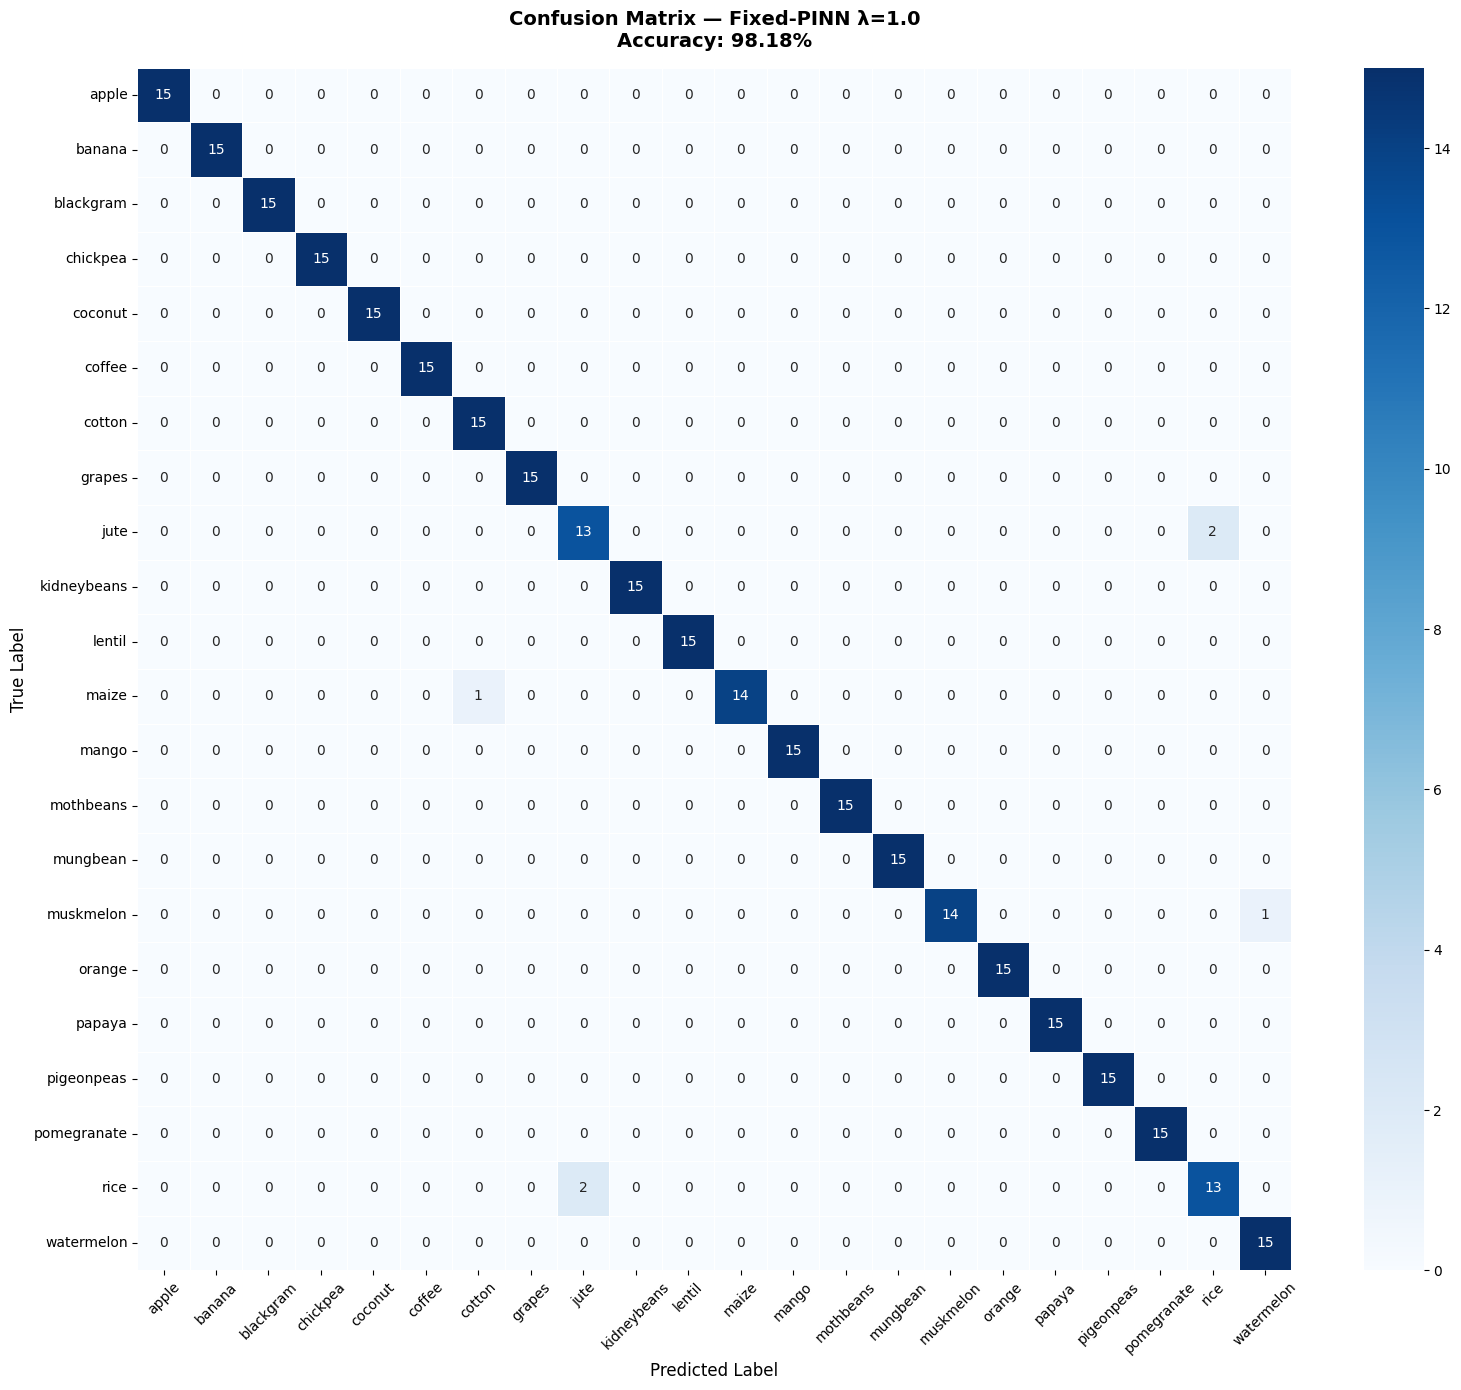

✅ Confusion matrix Fixed-PINN λ=1.0 disimpan

=== MISCLASSIFIKASI Fixed-PINN λ=1.0 ===
  jute            → diprediksi rice            : 2 sampel
  maize           → diprediksi cotton          : 1 sampel
  muskmelon       → diprediksi watermelon      : 1 sampel
  rice            → diprediksi jute            : 2 sampel

  Total salah: 6 dari 330 sampel test



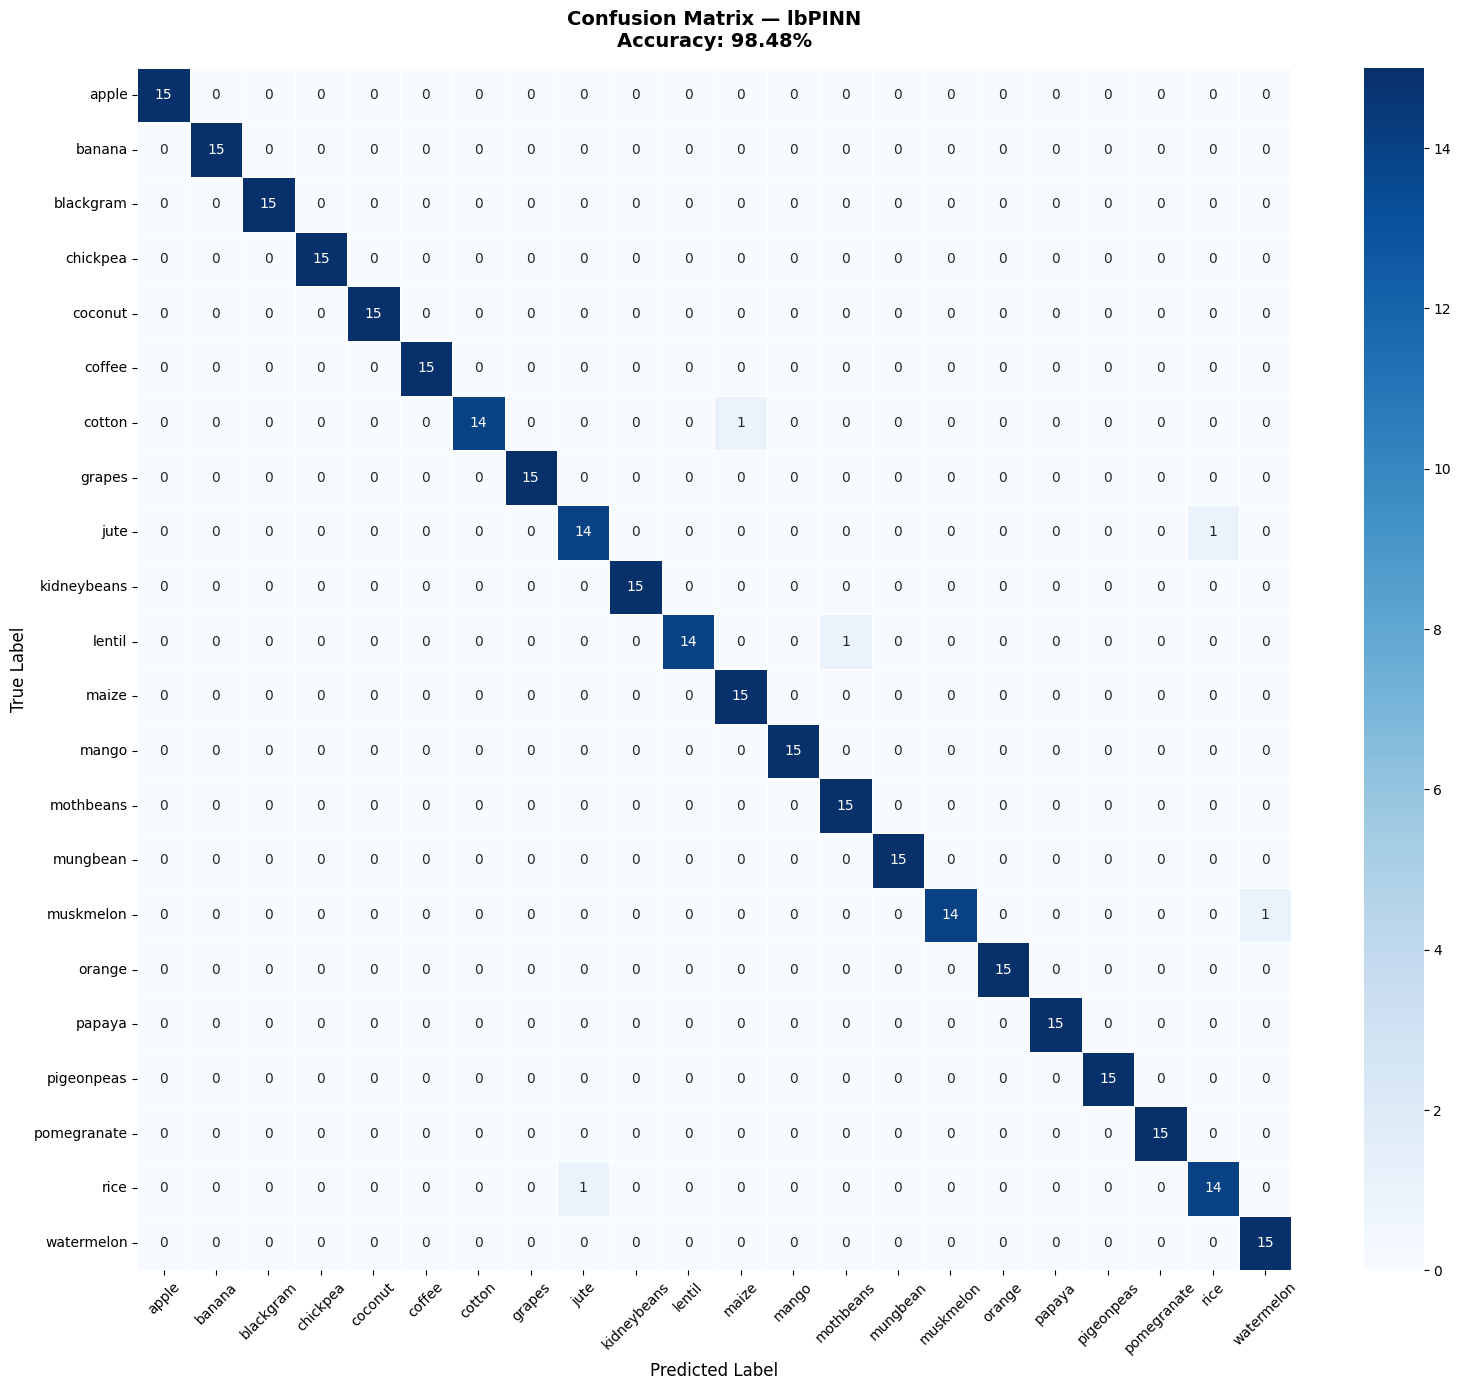

✅ Confusion matrix lbPINN disimpan

=== MISCLASSIFIKASI lbPINN ===
  cotton          → diprediksi maize           : 1 sampel
  jute            → diprediksi rice            : 1 sampel
  lentil          → diprediksi mothbeans       : 1 sampel
  muskmelon       → diprediksi watermelon      : 1 sampel
  rice            → diprediksi jute            : 1 sampel

  Total salah: 5 dari 330 sampel test



In [95]:
# ============================================================
# CELL 11: Confusion Matrix & Classification Report
# Rujukan: BAB 3 hal 58-60
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

def plot_confusion_matrix(results, model_name):
    """Plot confusion matrix dengan label nama tanaman"""
    
    cm          = results['confusion_matrix']
    class_names = list(le.classes_)
    
    fig, ax = plt.subplots(figsize=(16, 14))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5
    )
    
    ax.set_title(f'Confusion Matrix — {model_name}\n'
                 f'Accuracy: {results["accuracy"]*100:.2f}%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix {model_name} disimpan")

def print_misclassified(results, model_name):
    """Tampilkan kelas yang salah diprediksi"""
    cm          = results['confusion_matrix']
    class_names = list(le.classes_)
    
    print(f"\n=== MISCLASSIFIKASI {model_name} ===")
    total_errors = 0
    
    for i, true_class in enumerate(class_names):
        for j, pred_class in enumerate(class_names):
            if i != j and cm[i][j] > 0:
                print(f"  {true_class:15} → diprediksi {pred_class:15} "
                      f": {cm[i][j]} sampel")
                total_errors += cm[i][j]
    
    print(f"\n  Total salah: {total_errors} dari "
          f"{results['confusion_matrix'].sum()} sampel test")

# Plot dan analisis ketiga model
for results, name in [
    (results_baseline, "Baseline MLP"),
    (results_pinn,     "Fixed-PINN λ=1.0"),
    (results_lbpinn,   "lbPINN")
]:
    plot_confusion_matrix(results, name)
    print_misclassified(results, name)
    print()